## sample size optomizer

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import string
import os
import json
import time

# Force file paths to be relative to the script location (works in both Python script & Jupyter)
try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR = os.getcwd()

INPUT_TEXT_FILE = os.path.join(BASE_DIR, 'The home book of verse processed.txt')

# Default Enigma configuration
DEFAULT_ROTOR_ORDER = ['III', 'II', 'I']  # Left-Middle-Right
DEFAULT_POSITIONS   = [0, 0, 0]           # Starting positions (A-A-A)

# Training configuration
MESSAGE_LENGTH = 100  # Fixed message length for this optimizer
NUM_EPOCHS     = 8
STEP_SIZE      = 100

# ============================================================================
# TRAINING SAMPLES OPTIMIZER CONFIGURATION
# ============================================================================
# List of training sample counts to try. Add or remove values as needed.
TRAINING_SAMPLES_TO_TRY = [500, 1000, 2500, 5000, 10000, 20000, 50000, 100000,  250000, 1500000]

# Results file — optimizer writes here after every run so progress is never lost
OPTIMIZER_RESULTS_FILE = os.path.join(BASE_DIR, 'sample_optimizer_results.json')


# ============================================================================
# ENIGMA SIMULATOR (Simplified - no plugboard)
# ============================================================================
class SimpleEnigma:
    """Simplified Enigma machine simulator"""

    ROTORS = {
        'I':   'EKMFLGDQVZNTOWYHXUSPAIBRCJ',
        'II':  'AJDKSIRUXBLHWTMCQGZNPYFVOE',
        'III': 'BDFHJLCPRTXVZNYEIWGAKMUSQO',
        'IV':  'ESOVPZJAYQUIRHXLNFTGKDCMWB',
        'V':   'VZBRGITYUPSDNHLXAWMJQOFECK'
    }

    NOTCHES = {
        'I': 'Q', 'II': 'E', 'III': 'V', 'IV': 'J', 'V': 'Z'
    }

    REFLECTOR = 'YRUHQSLDPXNGOKMIEBFZCWVJAT'

    def __init__(self, rotors, positions):
        self.rotors            = [self.ROTORS[r] for r in rotors]
        self.rotor_names       = rotors
        self.positions         = positions.copy()
        self.initial_positions = positions.copy()

    def reset(self):
        self.positions = self.initial_positions.copy()

    def set_positions(self, positions):
        self.positions = positions.copy()

    def get_positions(self):
        return self.positions.copy()

    def step_rotors(self):
        if self.rotor_at_notch(1):
            self.positions[1] = (self.positions[1] + 1) % 26
            self.positions[2] = (self.positions[2] + 1) % 26
        elif self.rotor_at_notch(0):
            self.positions[1] = (self.positions[1] + 1) % 26
        self.positions[0] = (self.positions[0] + 1) % 26

    def rotor_at_notch(self, rotor_index):
        notch     = self.NOTCHES[self.rotor_names[rotor_index]]
        notch_pos = ord(notch) - ord('A')
        return self.positions[rotor_index] == notch_pos

    def encrypt_char(self, char):
        if char not in string.ascii_uppercase:
            return char
        self.step_rotors()
        pos = ord(char) - ord('A')
        for i in range(3):
            pos = (pos + self.positions[i]) % 26
            pos = ord(self.rotors[i][pos]) - ord('A')
            pos = (pos - self.positions[i]) % 26
        pos = ord(self.REFLECTOR[pos]) - ord('A')
        for i in range(2, -1, -1):
            pos = (pos + self.positions[i]) % 26
            pos = self.rotors[i].index(chr(pos + ord('A')))
            pos = (pos - self.positions[i]) % 26
        return chr(pos + ord('A'))

    def encrypt(self, text):
        result = []
        for char in text.upper():
            result.append(self.encrypt_char(char))
        return ''.join(result)


# ============================================================================
# FILE READING AND DATA PREPARATION
# ============================================================================
def read_text_from_file(filename):
    if not os.path.exists(filename):
        raise FileNotFoundError(f"Input file '{filename}' not found!")
    letters = []
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip().upper()
            for char in line:
                if char in string.ascii_uppercase:
                    letters.append(char)
    text = ''.join(letters)
    print(f"Read {len(text)} letters from '{filename}'")
    return text


def generate_dataset_continuous(filename, rotor_order, initial_positions,
                                num_samples=5000, message_length=100,
                                step_size=STEP_SIZE):
    full_plaintext = read_text_from_file(filename)

    total_chars_needed = (num_samples * step_size) + message_length
    if len(full_plaintext) < total_chars_needed:
        repeats        = (total_chars_needed // len(full_plaintext)) + 1
        full_plaintext = full_plaintext * repeats

    print(f"\nGenerating {num_samples} training samples...")
    print(f"Rotor order: {rotor_order}   Initial positions: {initial_positions} "
          f"({chr(initial_positions[0]+65)}{chr(initial_positions[1]+65)}{chr(initial_positions[2]+65)})")

    enigma          = SimpleEnigma(rotor_order, initial_positions)
    full_ciphertext = enigma.encrypt(full_plaintext)

    enigma.set_positions(initial_positions)
    data = []

    for i in range(num_samples):
        if (i + 1) % 1000 == 0:
            print(f"  Extracted {i + 1}/{num_samples} samples")

        start_idx       = i * step_size
        plaintext       = full_plaintext[start_idx:start_idx + message_length]
        ciphertext      = full_ciphertext[start_idx:start_idx + message_length]
        chunk_positions = enigma.get_positions()

        for char in full_plaintext[start_idx:start_idx + step_size]:
            if char in string.ascii_uppercase:
                enigma.step_rotors()

        data.append({
            'ciphertext': ciphertext,
            'plaintext':  plaintext,
            'rotors':     rotor_order,
            'positions':  chunk_positions
        })

    unique_positions = {tuple(item['positions']) for item in data}
    print(f"\n✓ Dataset generated | Unique position combos: {len(unique_positions)}")
    print(f"  First sample positions: {data[0]['positions']}   "
          f"Last: {data[-1]['positions']}")
    return data


# ============================================================================
# PYTORCH DATASET
# ============================================================================
class EnigmaDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item               = self.data[idx]
        ciphertext_encoded = self.encode_text(item['ciphertext'])
        positions          = torch.tensor(item['positions'], dtype=torch.long)
        return ciphertext_encoded, positions

    @staticmethod
    def encode_text(text):
        encoded = torch.zeros(len(text), 26)
        for i, char in enumerate(text):
            if char in string.ascii_uppercase:
                encoded[i, ord(char) - ord('A')] = 1
        return encoded


# ============================================================================
# NEURAL NETWORK MODEL
# ============================================================================
class EnigmaRotorClassifier(nn.Module):
    def __init__(self, message_length=100, hidden_dim=1024):
        super(EnigmaRotorClassifier, self).__init__()

        self.conv1 = nn.Conv1d(26,   64,   kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(64,   128,  kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(128,  256,  kernel_size=3, padding=1)
        self.conv4 = nn.Conv1d(256,  512,  kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(512,  1024, kernel_size=3, padding=1)

        self.pool    = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.3)

        # Dynamically compute the flattened size so any message_length works
        with torch.no_grad():
            dummy         = torch.zeros(1, 26, message_length)
            dummy         = self.pool(torch.relu(self.conv1(dummy)))
            dummy         = self.pool(torch.relu(self.conv2(dummy)))
            dummy         = self.pool(torch.relu(self.conv3(dummy)))
            dummy         = self.pool(torch.relu(self.conv4(dummy)))
            dummy         = self.pool(torch.relu(self.conv5(dummy)))
            conv_out_size = dummy.view(1, -1).shape[1]

        self.fc1 = nn.Linear(conv_out_size, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim,    hidden_dim)

        self.rotor1_head = nn.Linear(hidden_dim, 26)
        self.rotor2_head = nn.Linear(hidden_dim, 26)
        self.rotor3_head = nn.Linear(hidden_dim, 26)

        self.relu        = nn.ReLU()
        self.batch_norm1 = nn.BatchNorm1d(64)
        self.batch_norm2 = nn.BatchNorm1d(128)
        self.batch_norm3 = nn.BatchNorm1d(256)
        self.batch_norm4 = nn.BatchNorm1d(512)
        self.batch_norm5 = nn.BatchNorm1d(1024)

    def forward(self, x):
        x = x.transpose(1, 2)

        x = self.relu(self.batch_norm1(self.conv1(x)))
        x = self.pool(x)
        x = self.relu(self.batch_norm2(self.conv2(x)))
        x = self.pool(x)
        x = self.relu(self.batch_norm3(self.conv3(x)))
        x = self.pool(x)
        x = self.relu(self.batch_norm4(self.conv4(x)))
        x = self.pool(x)
        x = self.relu(self.batch_norm5(self.conv5(x)))
        x = self.pool(x)

        x = x.view(x.size(0), -1)
        x = self.dropout(x)

        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))

        return self.rotor1_head(x), self.rotor2_head(x), self.rotor3_head(x)


# ============================================================================
# TRAINING
# ============================================================================
def train_model(model, train_loader, val_loader, num_epochs=NUM_EPOCHS,
                device='cuda', model_save_path='best_enigma_model.pth'):
    model     = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)

    best_val_acc  = 0.0
    epoch_history = []

    for epoch in range(num_epochs):
        # ── Training ──────────────────────────────────────────────────────
        model.train()
        train_loss    = 0.0
        train_correct = [0, 0, 0]
        train_total   = 0

        for ciphertext, positions in train_loader:
            ciphertext = ciphertext.to(device)
            positions  = positions.to(device)
            optimizer.zero_grad()

            out1, out2, out3 = model(ciphertext)
            loss = (nn.CrossEntropyLoss()(out1, positions[:, 0]) +
                    nn.CrossEntropyLoss()(out2, positions[:, 1]) +
                    nn.CrossEntropyLoss()(out3, positions[:, 2]))
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            for i, out in enumerate([out1, out2, out3]):
                _, pred = torch.max(out, 1)
                train_correct[i] += (pred == positions[:, i]).sum().item()
            train_total += positions.size(0)

        # ── Validation ────────────────────────────────────────────────────
        model.eval()
        val_loss    = 0.0
        val_correct = [0, 0, 0]
        val_total   = 0

        with torch.no_grad():
            for ciphertext, positions in val_loader:
                ciphertext = ciphertext.to(device)
                positions  = positions.to(device)
                out1, out2, out3 = model(ciphertext)
                val_loss += (nn.CrossEntropyLoss()(out1, positions[:, 0]) +
                             nn.CrossEntropyLoss()(out2, positions[:, 1]) +
                             nn.CrossEntropyLoss()(out3, positions[:, 2])).item()
                for i, out in enumerate([out1, out2, out3]):
                    _, pred = torch.max(out, 1)
                    val_correct[i] += (pred == positions[:, i]).sum().item()
                val_total += positions.size(0)

        train_acc   = [(c / train_total) * 100 for c in train_correct]
        val_acc     = [(c / val_total)   * 100 for c in val_correct]
        avg_val_acc = sum(val_acc) / 3

        scheduler.step(val_loss)

        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print(f'  Train Loss: {train_loss/len(train_loader):.4f}  |  '
              f'Acc R1:{train_acc[0]:.1f}%  R2:{train_acc[1]:.1f}%  R3:{train_acc[2]:.1f}%')
        print(f'  Val   Loss: {val_loss/len(val_loader):.4f}  |  '
              f'Acc R1:{val_acc[0]:.1f}%  R2:{val_acc[1]:.1f}%  R3:{val_acc[2]:.1f}%')

        epoch_history.append({
            'epoch':       epoch + 1,
            'train_acc':   train_acc,
            'val_acc':     val_acc,
            'avg_val_acc': avg_val_acc,
        })

        if avg_val_acc > best_val_acc:
            best_val_acc = avg_val_acc
            torch.save(model.state_dict(), model_save_path)
            print(f'  ✓ Saved best model  (avg val acc: {avg_val_acc:.2f}%)')

    return model, epoch_history


# ============================================================================
# EVALUATION
# ============================================================================
def predict_positions(model, ciphertext, device='cuda'):
    model.eval()
    encoded = EnigmaDataset.encode_text(ciphertext).unsqueeze(0).to(device)
    with torch.no_grad():
        out1, out2, out3 = model(encoded)
        preds = [torch.max(o, 1)[1].item() for o in [out1, out2, out3]]
        confs = [torch.softmax(o, dim=1)[0, p].item() * 100
                 for o, p in zip([out1, out2, out3], preds)]
    return preds, confs


def evaluate_accuracy(model, data, dataset_name, device, verbose=True):
    """Return per-rotor accuracy list and all-correct accuracy."""
    model.eval()
    correct_per_rotor = [0, 0, 0]
    all_correct       = 0
    total             = len(data)

    for sample in data:
        predictions, _ = predict_positions(model, sample['ciphertext'], device)
        true_positions  = sample['positions']
        rotor_correct   = [predictions[i] == true_positions[i] for i in range(3)]
        for i in range(3):
            if rotor_correct[i]:
                correct_per_rotor[i] += 1
        if all(rotor_correct):
            all_correct += 1

    per_rotor_pct   = [c / total * 100 for c in correct_per_rotor]
    all_correct_pct = all_correct / total * 100

    if verbose:
        print(f'\n{dataset_name} ({total} samples):')
        for i in range(3):
            print(f'  Rotor {i+1} accuracy: {per_rotor_pct[i]:.2f}%')
        print(f'  All 3 rotors correct: {all_correct_pct:.2f}%  ({all_correct}/{total})')

    return per_rotor_pct, all_correct_pct


# ============================================================================
# TRAINING SAMPLES OPTIMIZER
# ============================================================================
def run_optimizer(sample_counts, device):
    """
    Loop over each candidate training sample count, train a fresh model,
    evaluate it, and record the results. Saves a running JSON log after every
    run so no progress is lost if the process is interrupted.

    Returns a list of result dicts sorted by validation all-correct accuracy.
    """

    print('\n' + '=' * 60)
    print('TRAINING SAMPLES OPTIMIZER')
    print(f'Sample counts to evaluate: {sample_counts}')
    print(f'Fixed message length: {MESSAGE_LENGTH}')
    print('=' * 60)

    all_results = []

    for num_samples in sample_counts:
        print(f'\n{"#" * 60}')
        print(f'  TRYING NUM_TRAINING_SAMPLES = {num_samples:,}')
        print(f'{"#" * 60}')

        run_start = time.time()

        # ── 1. Generate dataset ──────────────────────────────────────────
        dataset = generate_dataset_continuous(
            filename          = INPUT_TEXT_FILE,
            rotor_order       = DEFAULT_ROTOR_ORDER,
            initial_positions = DEFAULT_POSITIONS,
            num_samples       = num_samples,
            message_length    = MESSAGE_LENGTH,
            step_size         = 1,
        )

        split_idx    = int(0.8 * len(dataset))
        train_data   = dataset[:split_idx]
        val_data     = dataset[split_idx:]

        train_loader = DataLoader(EnigmaDataset(train_data), batch_size=32, shuffle=True)
        val_loader   = DataLoader(EnigmaDataset(val_data),   batch_size=32, shuffle=False)

        print(f'\nTrain: {len(train_data):,}  |  Val: {len(val_data):,}')

        # ── 2. Build & train model ───────────────────────────────────────
        model_save = os.path.join(BASE_DIR, f'enigma_model_nsamples{num_samples}.pth')

        model = EnigmaRotorClassifier(
            message_length = MESSAGE_LENGTH,
            hidden_dim     = 256,
        )
        total_params = sum(p.numel() for p in model.parameters())
        print(f'Model parameters: {total_params:,}')

        model, epoch_history = train_model(
            model,
            train_loader,
            val_loader,
            num_epochs      = NUM_EPOCHS,
            device          = device,
            model_save_path = model_save,
        )

        # ── 3. Load best checkpoint for fair evaluation ──────────────────
        if os.path.exists(model_save):
            model.load_state_dict(torch.load(model_save, map_location=device))

        # ── 4. Evaluate ──────────────────────────────────────────────────
        print(f'\n--- Accuracy Report  (num_samples={num_samples:,}) ---')
        train_per_rotor, train_all = evaluate_accuracy(model, train_data, 'Training Set',   device)
        val_per_rotor,   val_all   = evaluate_accuracy(model, val_data,   'Validation Set', device)
        full_per_rotor,  full_all  = evaluate_accuracy(model, dataset,    'Full Dataset',   device)

        elapsed = time.time() - run_start

        result = {
            'num_samples':             num_samples,
            'train_size':              len(train_data),
            'val_size':                len(val_data),
            'total_params':            total_params,
            'elapsed_seconds':         round(elapsed, 1),
            # Validation (primary metric)
            'val_all_correct_pct':     round(val_all,              2),
            'val_per_rotor_pct':       [round(v, 2) for v in val_per_rotor],
            # Training
            'train_all_correct_pct':   round(train_all,            2),
            'train_per_rotor_pct':     [round(v, 2) for v in train_per_rotor],
            # Full dataset
            'full_all_correct_pct':    round(full_all,             2),
            'full_per_rotor_pct':      [round(v, 2) for v in full_per_rotor],
            # Epoch trace
            'epoch_history':           epoch_history,
        }
        all_results.append(result)

        # Save running log after each count so progress is never lost
        with open(OPTIMIZER_RESULTS_FILE, 'w') as f:
            json.dump(all_results, f, indent=2)
        print(f'\n  ⏱  Elapsed: {elapsed:.1f}s  |  Results saved → {OPTIMIZER_RESULTS_FILE}')

    return all_results


def print_optimizer_summary(results):
    """Pretty-print a ranked summary table of all optimizer runs."""

    ranked = sorted(results, key=lambda r: r['val_all_correct_pct'], reverse=True)

    print('\n' + '=' * 76)
    print('OPTIMIZER SUMMARY  —  ranked by validation all-correct %')
    print('=' * 76)
    print(f"{'Rank':<5} {'N Samples':<12} {'Val All%':<10} {'Trn All%':<10} "
          f"{'Val R1':>7} {'Val R2':>7} {'Val R3':>7} {'Time(s)':>9}")
    print('-' * 76)

    for rank, r in enumerate(ranked, start=1):
        vr     = r['val_per_rotor_pct']
        marker = '  ← BEST' if rank == 1 else ''
        print(f"{rank:<5} {r['num_samples']:<12,} {r['val_all_correct_pct']:<10.2f} "
              f"{r['train_all_correct_pct']:<10.2f} "
              f"{vr[0]:>7.1f} {vr[1]:>7.1f} {vr[2]:>7.1f} "
              f"{r['elapsed_seconds']:>9.1f}{marker}")

    print('=' * 76)
    best = ranked[0]
    print(f"\n✓ Best sample count:       {best['num_samples']:,}")
    print(f"  Validation all-correct:  {best['val_all_correct_pct']:.2f}%")
    print(f"  Training  all-correct:   {best['train_all_correct_pct']:.2f}%")

    # Diminishing-returns note: find the point where gains drop below 1 %
    by_size   = sorted(results, key=lambda r: r['num_samples'])
    prev_acc  = None
    threshold = 1.0
    print(f"\n  Diminishing-returns check (< {threshold}% gain between steps):")
    for r in by_size:
        acc = r['val_all_correct_pct']
        if prev_acc is not None:
            gain = acc - prev_acc
            flag = '  ← gains shrinking' if gain < threshold else ''
            print(f"    {r['num_samples']:>8,} samples → {acc:.2f}%  (Δ {gain:+.2f}%){flag}")
        else:
            print(f"    {r['num_samples']:>8,} samples → {acc:.2f}%  (baseline)")
        prev_acc = acc


# ============================================================================
# MAIN EXECUTION
# ============================================================================
if __name__ == '__main__':
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using device: {device}\n')

    # ── Run the optimizer across all candidate sample counts ────────────────
    optimizer_results = run_optimizer(
        sample_counts = TRAINING_SAMPLES_TO_TRY,
        device        = device,
    )

    # ── Print final ranked summary with diminishing-returns analysis ────────
    print_optimizer_summary(optimizer_results)

    # ── Detailed test on the best sample count ──────────────────────────────
    best_result  = max(optimizer_results, key=lambda r: r['val_all_correct_pct'])
    best_n       = best_result['num_samples']

    print(f'\n{"=" * 60}')
    print(f'DETAILED TEST ON BEST SAMPLE COUNT = {best_n:,}')
    print(f'{"=" * 60}')

    best_dataset = generate_dataset_continuous(
        filename          = INPUT_TEXT_FILE,
        rotor_order       = DEFAULT_ROTOR_ORDER,
        initial_positions = DEFAULT_POSITIONS,
        num_samples       = best_n,
        message_length    = MESSAGE_LENGTH,
        step_size         = 1,
    )

    best_model      = EnigmaRotorClassifier(message_length=MESSAGE_LENGTH, hidden_dim=256)
    best_model_path = os.path.join(BASE_DIR, f'enigma_model_nsamples{best_n}.pth')
    if os.path.exists(best_model_path):
        best_model.load_state_dict(torch.load(best_model_path, map_location=device))
    best_model = best_model.to(device)

    # Sample predictions
    test_indices = list(range(21)) + [50]
    for idx in test_indices:
        sample = best_dataset[idx]
        tp     = sample['positions']
        print(f'\n--- Sample {idx}  positions: {tp} '
              f'({chr(tp[0]+65)}{chr(tp[1]+65)}{chr(tp[2]+65)}) ---')
        print(f'  Cipher: {sample["ciphertext"][:50]}...')
        preds, confs = predict_positions(best_model, sample['ciphertext'], device)
        for i in range(3):
            status = '✓' if preds[i] == tp[i] else '✗'
            print(f'  Rotor {i+1}: pred={chr(preds[i]+65)}  true={chr(tp[i]+65)}'
                  f'  conf={confs[i]:.1f}%  {status}')

    print('\n' + '=' * 60)
    print('ALL RUNS COMPLETE')
    print(f'Full results saved to: {OPTIMIZER_RESULTS_FILE}')
    print('=' * 60)

Using device: cuda


TRAINING SAMPLES OPTIMIZER
Sample counts to evaluate: [500, 1000, 2500, 5000, 10000, 20000, 50000, 100000, 250000, 1500000]
Fixed message length: 100

############################################################
  TRYING NUM_TRAINING_SAMPLES = 500
############################################################
Read 4396326 letters from 'C:\Users\acool\1 Capstone\Engima-Capstone-main\The home book of verse processed.txt'

Generating 500 training samples...
Rotor order: ['III', 'II', 'I']   Initial positions: [0, 0, 0] (AAA)

✓ Dataset generated | Unique position combos: 500
  First sample positions: [0, 0, 0]   Last: [5, 20, 1]

Train: 400  |  Val: 100
Model parameters: 2,972,430

Epoch 1/8
  Train Loss: 6.7927  |  Acc R1:2.2%  R2:26.0%  R3:80.5%
  Val   Loss: 8.1115  |  Acc R1:4.0%  R2:0.0%  R3:100.0%
  ✓ Saved best model  (avg val acc: 34.67%)

Epoch 2/8
  Train Loss: 4.4386  |  Acc R1:3.0%  R2:79.2%  R3:98.5%
  Val   Loss: 8.3449  |  Acc R1:4.0%  R2:9.0%  R3:100.0%


## sample accuracy

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import string
import os

# Force file paths to be relative to the script location (works in both Python script & Jupyter)
try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR = os.getcwd()

INPUT_TEXT_FILE = os.path.join(BASE_DIR, 'The home book of verse processed.txt')

# Default Enigma configuration
DEFAULT_ROTOR_ORDER = ['III', 'II', 'I']  # Left-Middle-Right
DEFAULT_POSITIONS = [0, 0, 0]  # Starting positions (A-A-A)

# Training configuration
MESSAGE_LENGTH = 100  # How many characters to use per training sample
NUM_TRAINING_SAMPLES = 5000  # Number of encrypted samples to generate
NUM_EPOCHS  = 8
STEP_SIZE   = 100


# ============================================================================
# ENIGMA SIMULATOR (Simplified - no plugboard)
# ============================================================================
class SimpleEnigma:
    """Simplified Enigma machine simulator"""
    
    # Historical rotor wirings (I-V)
    ROTORS = {
        'I':   'EKMFLGDQVZNTOWYHXUSPAIBRCJ',
        'II':  'AJDKSIRUXBLHWTMCQGZNPYFVOE',
        'III': 'BDFHJLCPRTXVZNYEIWGAKMUSQO',
        'IV':  'ESOVPZJAYQUIRHXLNFTGKDCMWB',
        'V':   'VZBRGITYUPSDNHLXAWMJQOFECK'
    }
    
    # Notch positions (when rotor steps the next one)
    NOTCHES = {
        'I': 'Q', 'II': 'E', 'III': 'V', 'IV': 'J', 'V': 'Z'
    }
    
    REFLECTOR = 'YRUHQSLDPXNGOKMIEBFZCWVJAT'
    
    def __init__(self, rotors, positions):
        """
        rotors: list of 3 rotor names, e.g., ['III', 'II', 'I']
        positions: list of 3 starting positions (0-25)
        """
        self.rotors = [self.ROTORS[r] for r in rotors]
        self.rotor_names = rotors
        self.positions = positions.copy()
        self.initial_positions = positions.copy()
    
    def reset(self):
        """Reset rotor positions to initial state"""
        self.positions = self.initial_positions.copy()
    
    def set_positions(self, positions):
        """Set rotor positions to specific values"""
        self.positions = positions.copy()
    
    def get_positions(self):
        """Get current rotor positions"""
        return self.positions.copy()
    
    def step_rotors(self):
        """Advance rotors according to Enigma stepping rules"""
        # Check for double-stepping of middle rotor
        if self.rotor_at_notch(1):
            self.positions[1] = (self.positions[1] + 1) % 26
            self.positions[2] = (self.positions[2] + 1) % 26
        elif self.rotor_at_notch(0):
            self.positions[1] = (self.positions[1] + 1) % 26
        
        # Always step the rightmost rotor
        self.positions[0] = (self.positions[0] + 1) % 26
    
    def rotor_at_notch(self, rotor_index):
        """Check if rotor is at its notch position"""
        notch = self.NOTCHES[self.rotor_names[rotor_index]]
        notch_pos = ord(notch) - ord('A')
        return self.positions[rotor_index] == notch_pos
    
    def encrypt_char(self, char):
        """Encrypt a single character"""
        if char not in string.ascii_uppercase:
            return char
        
        # Step rotors before encryption
        self.step_rotors()
        
        # Convert char to number (A=0, B=1, ...)
        pos = ord(char) - ord('A')
        
        # Forward through rotors (right to left)
        for i in range(3):
            pos = (pos + self.positions[i]) % 26
            pos = ord(self.rotors[i][pos]) - ord('A')
            pos = (pos - self.positions[i]) % 26
        
        # Through reflector
        pos = ord(self.REFLECTOR[pos]) - ord('A')
        
        # Backward through rotors (left to right)
        for i in range(2, -1, -1):
            pos = (pos + self.positions[i]) % 26
            pos = self.rotors[i].index(chr(pos + ord('A')))
            pos = (pos - self.positions[i]) % 26
        
        return chr(pos + ord('A'))
    
    def encrypt(self, text):
        """Encrypt a full message WITHOUT resetting positions"""
        result = []
        for char in text.upper():
            result.append(self.encrypt_char(char))
        return ''.join(result)

# ============================================================================
# FILE READING AND DATA PREPARATION
# ============================================================================
def read_text_from_file(filename):
    """
    Read text from a file with one letter per line
    Returns a string of uppercase letters only
    """
    if not os.path.exists(filename):
        raise FileNotFoundError(f"Input file '{filename}' not found!")
    
    letters = []
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip().upper()
            # Only keep valid letters
            for char in line:
                if char in string.ascii_uppercase:
                    letters.append(char)
    
    text = ''.join(letters)
    print(f"Read {len(text)} letters from '{filename}'")
    return text

def generate_dataset_continuous(filename, rotor_order, initial_positions, 
                                num_samples=5000, message_length=100,
                                step_size=STEP_SIZE):
    # Read plaintext from file
    full_plaintext = read_text_from_file(filename)
    
    total_chars_needed = (num_samples * step_size) + message_length
    if len(full_plaintext) < total_chars_needed:
        print(f"WARNING: File has {len(full_plaintext)} letters but need {total_chars_needed}")
        print(f"Will repeat the text to generate enough samples")
        repeats = (total_chars_needed // len(full_plaintext)) + 1
        full_plaintext = full_plaintext * repeats
    
    data = []
    print(f"\nGenerating {num_samples} training samples with continuous rotor advancement...")
    print(f"Rotor order: {rotor_order} (Left-Middle-Right)")
    print(f"Initial positions: {initial_positions} ({chr(initial_positions[0]+65)}{chr(initial_positions[1]+65)}{chr(initial_positions[2]+65)})")
    
    # Create enigma machine with starting configuration
    enigma = SimpleEnigma(rotor_order, initial_positions)
    
    # Encrypt the ENTIRE text in one continuous stream
    print(f"\nEncrypting {len(full_plaintext)} characters continuously...")
    full_ciphertext = enigma.encrypt(full_plaintext)
    print(f"✓ Encryption complete")
    
    # Reset enigma to track positions during extraction
    enigma.set_positions(initial_positions)
    
    print(f"\nExtracting {num_samples} samples with rotor position tracking...")
    
    for i in range(num_samples):                              # ← loop starts
        if (i + 1) % 1000 == 0:
            print(f"  Extracted {i + 1}/{num_samples} samples")
        
        start_idx = i * step_size                            # ← indented inside loop
        
        plaintext  = full_plaintext[start_idx:start_idx + message_length]
        ciphertext = full_ciphertext[start_idx:start_idx + message_length]
        
        chunk_positions = enigma.get_positions()             # ← record position
        
        for char in full_plaintext[start_idx:start_idx + step_size]:
            if char in string.ascii_uppercase:
                enigma.step_rotors()                         # ← advance by step_size only
        
        data.append({                                        # ← append inside outer loop
            'ciphertext': ciphertext,
            'plaintext': plaintext,
            'rotors': rotor_order,
            'positions': chunk_positions
        })
    
    # Print statistics about position variation
    unique_positions = set()
    for item in data:
        pos_tuple = tuple(item['positions'])
        unique_positions.add(pos_tuple)
    
    print(f"\n✓ Dataset generated successfully")
    print(f"  Unique rotor position combinations: {len(unique_positions)}")
    print(f"  First sample positions: {data[0]['positions']} ({chr(data[0]['positions'][0]+65)}{chr(data[0]['positions'][1]+65)}{chr(data[0]['positions'][2]+65)})")
    print(f"  Last sample positions:  {data[-1]['positions']} ({chr(data[-1]['positions'][0]+65)}{chr(data[-1]['positions'][1]+65)}{chr(data[-1]['positions'][2]+65)})")
    
    return data

# ============================================================================
# PYTORCH DATASET
# ============================================================================
class EnigmaDataset(Dataset):
    """PyTorch dataset for Enigma encrypted messages"""
    
    def __init__(self, data):
        self.data = data
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        item = self.data[idx]
        
        # Convert ciphertext to one-hot encoded tensor
        ciphertext_encoded = self.encode_text(item['ciphertext'])
        
        # Convert positions to tensor (3 values, each 0-25)
        positions = torch.tensor(item['positions'], dtype=torch.long)
        
        return ciphertext_encoded, positions
    
    @staticmethod
    def encode_text(text):
        """Convert text to one-hot encoded tensor"""
        # Create tensor of shape (seq_len, 26)
        encoded = torch.zeros(len(text), 26)
        for i, char in enumerate(text):
            if char in string.ascii_uppercase:
                encoded[i, ord(char) - ord('A')] = 1
        return encoded

# ============================================================================
# NEURAL NETWORK MODEL
# ============================================================================
class EnigmaRotorClassifier(nn.Module):
    """
    CNN-based model to predict rotor positions from encrypted text
    
    OPTIMIZATION NOTES:
    - To change the number of convolutional layers, add/remove conv layers
    - To change the number of nodes in conv layers, modify the channel numbers
      (currently: 64 -> 128 -> 256)
    - To change the number of fully connected layers, add/remove fc layers
    - To change the number of nodes in FC layers, modify hidden_dim parameter
      (currently: 256)
    """
    
    def __init__(self, message_length=100, hidden_dim=1024):
        """
        Args:
            message_length: Length of input message
            hidden_dim: Number of nodes in fully connected layers
                       *** CHANGE THIS TO ADJUST FC LAYER SIZE ***
        """
        super(EnigmaRotorClassifier, self).__init__()
        
        # ====================================================================
        # CONVOLUTIONAL LAYERS - MODIFY NUMBER OF LAYERS AND NODES HERE
        # ====================================================================
        # Current architecture: 3 conv layers with 64, 128, 256 channels
        # To add more layers: add self.conv4, self.batch_norm4, etc.
        # To change nodes: modify the channel numbers (e.g., 64 -> 128)
        
        self.conv1 = nn.Conv1d(26, 64, kernel_size=3, padding=1)      # *** 64 nodes ***
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)     # *** 128 nodes ***
        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, padding=1)    # *** 256 nodes ***
        self.conv4 = nn.Conv1d(256, 512, kernel_size=3, padding=1)    # *** 512 nodes ***
        self.conv5 = nn.Conv1d(512, 1024, kernel_size=3, padding=1)    # *** 1024 nodes ***
        
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.3)
        
        # Calculate flattened size after convolutions
        # NOTE: If you change number of conv layers, adjust the divisor
        # Currently: 3 conv layers with pooling = divide by 2^3 = 8
        conv_output_size = message_length // 8 * 256  # 256 is last conv layer size
        
        # ====================================================================
        # FULLY CONNECTED LAYERS - MODIFY NUMBER OF LAYERS AND NODES HERE
        # ====================================================================
        # Current architecture: 2 FC layers with hidden_dim nodes each
        # To add more layers: add self.fc3, self.fc4, etc. and update forward()
        # To change nodes: modify hidden_dim parameter when creating model
        
        self.fc1 = nn.Linear(conv_output_size, hidden_dim)  # *** hidden_dim nodes ***
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)        # *** hidden_dim nodes ***
        
        # Three output heads (one for each rotor position, 26 classes each)
        self.rotor1_head = nn.Linear(hidden_dim, 26)
        self.rotor2_head = nn.Linear(hidden_dim, 26)
        self.rotor3_head = nn.Linear(hidden_dim, 26)
        
        self.relu = nn.ReLU()
        self.batch_norm1 = nn.BatchNorm1d(64)
        self.batch_norm2 = nn.BatchNorm1d(128)
        self.batch_norm3 = nn.BatchNorm1d(256)
        self.batch_norm4 = nn.BatchNorm1d(512)
        self.batch_norm5 = nn.BatchNorm1d(1024)
        
    
    def forward(self, x):
        # x shape: (batch_size, seq_len, 26)
        # Conv1d expects (batch_size, channels, seq_len)
        x = x.transpose(1, 2)
        
        # ====================================================================
        # FORWARD PASS THROUGH CONVOLUTIONAL LAYERS
        # If you add/remove conv layers, update this section
        # ====================================================================
        x = self.relu(self.batch_norm1(self.conv1(x)))
        x = self.pool(x)
        
        x = self.relu(self.batch_norm2(self.conv2(x)))
        x = self.pool(x)
        
        x = self.relu(self.batch_norm3(self.conv3(x)))
        x = self.pool(x)

        x = self.relu(self.batch_norm4(self.conv4(x)))
        x = self.pool(x)

        x = self.relu(self.batch_norm5(self.conv5(x)))
        x = self.pool(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        
        # ====================================================================
        # FORWARD PASS THROUGH FULLY CONNECTED LAYERS
        # If you add/remove FC layers, update this section
        # ====================================================================
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        
        # Output predictions for each rotor
        rotor1_out = self.rotor1_head(x)
        rotor2_out = self.rotor2_head(x)
        rotor3_out = self.rotor3_head(x)
        
        return rotor1_out, rotor2_out, rotor3_out

# ============================================================================
# TRAINING FUNCTIONS
# ============================================================================
def train_model(model, train_loader, val_loader, num_epochs=NUM_EPOCHS, device='cuda'):
    """Train the Enigma rotor classifier"""
    
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)
    
    best_val_acc = 0.0
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = [0, 0, 0]
        train_total = 0
        
        for batch_idx, (ciphertext, positions) in enumerate(train_loader):
            ciphertext = ciphertext.to(device)
            positions = positions.to(device)
            
            optimizer.zero_grad()
            
            # Forward pass
            out1, out2, out3 = model(ciphertext)
            
            # Calculate loss for each rotor
            loss1 = criterion(out1, positions[:, 0])
            loss2 = criterion(out2, positions[:, 1])
            loss3 = criterion(out3, positions[:, 2])
            loss = loss1 + loss2 + loss3
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
            # Calculate accuracy
            _, pred1 = torch.max(out1, 1)
            _, pred2 = torch.max(out2, 1)
            _, pred3 = torch.max(out3, 1)
            
            train_correct[0] += (pred1 == positions[:, 0]).sum().item()
            train_correct[1] += (pred2 == positions[:, 1]).sum().item()
            train_correct[2] += (pred3 == positions[:, 2]).sum().item()
            train_total += positions.size(0)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = [0, 0, 0]
        val_total = 0
        
        with torch.no_grad():
            for ciphertext, positions in val_loader:
                ciphertext = ciphertext.to(device)
                positions = positions.to(device)
                
                out1, out2, out3 = model(ciphertext)
                
                loss1 = criterion(out1, positions[:, 0])
                loss2 = criterion(out2, positions[:, 1])
                loss3 = criterion(out3, positions[:, 2])
                loss = loss1 + loss2 + loss3
                
                val_loss += loss.item()
                
                _, pred1 = torch.max(out1, 1)
                _, pred2 = torch.max(out2, 1)
                _, pred3 = torch.max(out3, 1)
                
                val_correct[0] += (pred1 == positions[:, 0]).sum().item()
                val_correct[1] += (pred2 == positions[:, 1]).sum().item()
                val_correct[2] += (pred3 == positions[:, 2]).sum().item()
                val_total += positions.size(0)
        
        # Calculate accuracies
        train_acc = [(c / train_total) * 100 for c in train_correct]
        val_acc = [(c / val_total) * 100 for c in val_correct]
        avg_val_acc = sum(val_acc) / 3
        
        scheduler.step(val_loss)
        
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print(f'Train Loss: {train_loss/len(train_loader):.4f}')
        print(f'Train Acc - R1: {train_acc[0]:.2f}%, R2: {train_acc[1]:.2f}%, R3: {train_acc[2]:.2f}%')
        print(f'Val Loss: {val_loss/len(val_loader):.4f}')
        print(f'Val Acc - R1: {val_acc[0]:.2f}%, R2: {val_acc[1]:.2f}%, R3: {val_acc[2]:.2f}%')
        
        # Save best model
        if avg_val_acc > best_val_acc:
            best_val_acc = avg_val_acc
            torch.save(model.state_dict(), 'best_enigma_model.pth')
            print(f'✓ Saved best model with avg accuracy: {avg_val_acc:.2f}%')
    
    return model

# ============================================================================
# PREDICTION AND TESTING
# ============================================================================
def predict_positions(model, ciphertext, device='cuda'):
    """Predict rotor positions from encrypted message"""
    model.eval()
    
    # Encode ciphertext
    encoded = EnigmaDataset.encode_text(ciphertext).unsqueeze(0).to(device)
    
    with torch.no_grad():
        out1, out2, out3 = model(encoded)
        
        _, pred1 = torch.max(out1, 1)
        _, pred2 = torch.max(out2, 1)
        _, pred3 = torch.max(out3, 1)
        
        # Get confidence scores
        probs1 = torch.softmax(out1, dim=1)[0]
        probs2 = torch.softmax(out2, dim=1)[0]
        probs3 = torch.softmax(out3, dim=1)[0]
        
        confidence1 = probs1[pred1].item() * 100
        confidence2 = probs2[pred2].item() * 100
        confidence3 = probs3[pred3].item() * 100
    
    predictions = [pred1.item(), pred2.item(), pred3.item()]
    confidences = [confidence1, confidence2, confidence3]
    
    return predictions, confidences

# ============================================================================
# MAIN EXECUTION
# ============================================================================
if __name__ == '__main__':
    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using device: {device}\n')
    
    # Generate dataset with continuous rotor advancement
    print('=' * 60)
    print('GENERATING DATASET WITH CONTINUOUS ROTOR ADVANCEMENT')
    print('=' * 60)
    
    try:
        dataset = generate_dataset_continuous(
            filename=INPUT_TEXT_FILE,
            rotor_order=DEFAULT_ROTOR_ORDER,
            initial_positions=DEFAULT_POSITIONS,
            num_samples=NUM_TRAINING_SAMPLES,
            message_length=MESSAGE_LENGTH,
            step_size=1  
        )
    except FileNotFoundError as e:
        print(f"\nERROR: Input file '{INPUT_TEXT_FILE}' not found!")
        print("Please create this file with one letter per line.")
        print("Example content:")
        print("A")
        print("B")
        print("C")
        print("...")
        raise FileNotFoundError(f"Required input file '{INPUT_TEXT_FILE}' not found. Please create it first.") from e
    
    # Split into train/val
    split_idx = int(0.8 * len(dataset))
    train_data = dataset[:split_idx]
    val_data = dataset[split_idx:]
    
    train_dataset = EnigmaDataset(train_data)
    val_dataset = EnigmaDataset(val_data)
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    
    print(f'\nTraining samples: {len(train_data)}')
    print(f'Validation samples: {len(val_data)}')
    
    # Create model
    print('\n' + '=' * 60)
    print('CREATING MODEL')
    print('=' * 60)
    
    # ========================================================================
    # MODEL CREATION - CHANGE hidden_dim TO ADJUST FC LAYER SIZE
    # ========================================================================
    model = EnigmaRotorClassifier(
        message_length=MESSAGE_LENGTH,
        hidden_dim=256  # *** CHANGE THIS TO MODIFY FC LAYER SIZE ***
    )
    
    total_params = sum(p.numel() for p in model.parameters())
    print(f'Total parameters: {total_params:,}')
    
    # Train model
    print('\n' + '=' * 60)
    print('TRAINING MODEL')
    print('=' * 60)
    model = train_model(model, train_loader, val_loader, num_epochs=NUM_EPOCHS, device=device)
    
    # Test predictions on multiple samples with different positions
    print('\n' + '=' * 60)
    print('TESTING PREDICTIONS ON VARIED POSITIONS')
    print('=' * 60)
    
    # Test on first, middle, and last samples (different rotor positions)
    test_indices = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,50]
    
    for idx in test_indices:
        test_sample = dataset[idx]
        
        print(f'\n--- Test Sample {idx} ---')
        print(f'True positions: {test_sample["positions"]} ({chr(test_sample["positions"][0]+65)}{chr(test_sample["positions"][1]+65)}{chr(test_sample["positions"][2]+65)})')
        print(f'Ciphertext: {test_sample["ciphertext"][:50]}...')
        
        predictions, confidences = predict_positions(model, test_sample['ciphertext'], device)
        
        print(f'\nPredictions:')
        print(f'  Rotor 1: {predictions[0]} ({chr(predictions[0]+65)}) - Confidence: {confidences[0]:.1f}%')
        print(f'  Rotor 2: {predictions[1]} ({chr(predictions[1]+65)}) - Confidence: {confidences[1]:.1f}%')
        print(f'  Rotor 3: {predictions[2]} ({chr(predictions[2]+65)}) - Confidence: {confidences[2]:.1f}%')
        
        print(f'\nAccuracy:')
        print(f'  Rotor 1: {"✓ CORRECT" if predictions[0] == test_sample["positions"][0] else "✗ INCORRECT"}')
        print(f'  Rotor 2: {"✓ CORRECT" if predictions[1] == test_sample["positions"][1] else "✗ INCORRECT"}')
        print(f'  Rotor 3: {"✓ CORRECT" if predictions[2] == test_sample["positions"][2] else "✗ INCORRECT"}')
    
    print('\n' + '=' * 60)
    print('TRAINING COMPLETE')
    print('=' * 60)
    print('Model saved as: best_enigma_model.pth')

# ============================================================================
# FINAL ACCURACY EVALUATION
# ============================================================================
print('\n' + '=' * 60)
print('FINAL ACCURACY EVALUATION')
print('=' * 60)

def evaluate_accuracy(model, data, dataset_name, device):
    """Evaluate per-rotor and all-correct accuracy over a dataset."""
    model.eval()
    correct_per_rotor = [0, 0, 0]
    all_correct = 0
    total = len(data)

    for sample in data:
        predictions, _ = predict_positions(model, sample['ciphertext'], device)
        true_positions = sample['positions']

        rotor_correct = [predictions[i] == true_positions[i] for i in range(3)]
        for i in range(3):
            if rotor_correct[i]:
                correct_per_rotor[i] += 1
        if all(rotor_correct):
            all_correct += 1

    print(f'\n{dataset_name} ({total} samples):')
    for i in range(3):
        print(f'  Rotor {i+1} accuracy: {correct_per_rotor[i]/total*100:.2f}%')
    print(f'  All 3 rotors correct: {all_correct/total*100:.2f}%  ({all_correct}/{total})')

evaluate_accuracy(model, train_data, 'Training Set', device)
evaluate_accuracy(model, val_data,   'Validation Set', device)
evaluate_accuracy(model, dataset,    'Full Dataset', device)

Using device: cuda

GENERATING DATASET WITH CONTINUOUS ROTOR ADVANCEMENT
Read 4396326 letters from 'C:\Users\acool\1 Capstone\Engima-Capstone-main\The home book of verse processed.txt'

Generating 500000 training samples with continuous rotor advancement...
Rotor order: ['III', 'II', 'I'] (Left-Middle-Right)
Initial positions: [0, 0, 0] (AAA)

Encrypting 4396326 characters continuously...
✓ Encryption complete

Extracting 500000 samples with rotor position tracking...
  Extracted 1000/500000 samples
  Extracted 2000/500000 samples
  Extracted 3000/500000 samples
  Extracted 4000/500000 samples
  Extracted 5000/500000 samples
  Extracted 6000/500000 samples
  Extracted 7000/500000 samples
  Extracted 8000/500000 samples
  Extracted 9000/500000 samples
  Extracted 10000/500000 samples
  Extracted 11000/500000 samples
  Extracted 12000/500000 samples
  Extracted 13000/500000 samples
  Extracted 14000/500000 samples
  Extracted 15000/500000 samples
  Extracted 16000/500000 samples
  Extrac

## guess accuracy

Using device: cuda
Grid: message_lengths=[12, 25, 100]  ×  num_samples=[50, 200, 500, 1000, 5000, 15000]
Epochs per run: 30 | Batch size: 32 | Hidden dim: 256
Total training runs: 18

Loading input text file …
  Read 4396326 letters from 'C:\Users\acool\1 Capstone\Engima-Capstone-main\The home book of verse processed.txt'


RUN 1/18  |  msg_len=12  n_samples=50

  [MSG_LEN=  12, SAMPLES=   50]  generating data …
    Epoch  1/30  full_match=0.0%  (0/10 samples)  best=0.0%
    Epoch  2/30  full_match=0.0%  (0/10 samples)  best=0.0%
    Epoch  3/30  full_match=0.0%  (0/10 samples)  best=0.0%
    Epoch  4/30  full_match=0.0%  (0/10 samples)  best=0.0%
    Epoch  5/30  full_match=0.0%  (0/10 samples)  best=0.0%
    Epoch  6/30  full_match=0.0%  (0/10 samples)  best=0.0%
    Epoch  7/30  full_match=0.0%  (0/10 samples)  best=0.0%
    Epoch  8/30  full_match=0.0%  (0/10 samples)  best=0.0%
    Epoch  9/30  full_match=0.0%  (0/10 samples)  best=0.0%
    Epoch 10/30  full_match=0.0%  (0/10 samp

C:\Users\acool\AppData\Local\Temp\ipykernel_24992\236994685.py:338: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('plasma')



  Heatmap saved → C:\Users\acool\1 Capstone\Engima-Capstone-main\enigma_heatmap_20260417_142501.png


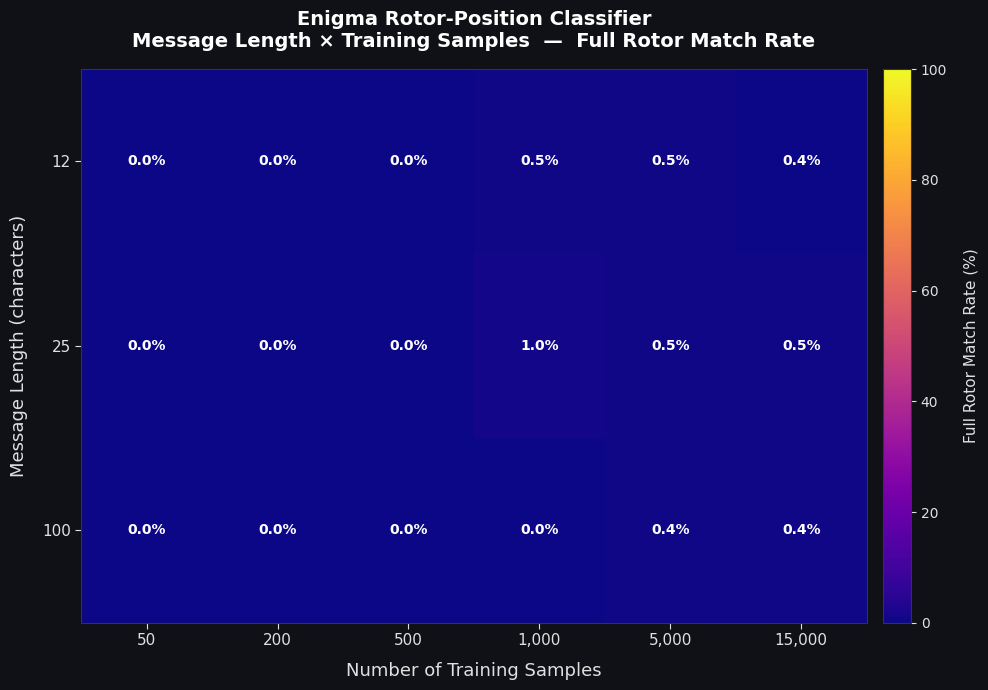


Done.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import string
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import itertools
import json
from datetime import datetime

# Force file paths to be relative to the script location
try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR = os.getcwd()

INPUT_TEXT_FILE = os.path.join(BASE_DIR, 'The home book of verse processed.txt')

# Default Enigma configuration (same as original)
DEFAULT_ROTOR_ORDER = ['III', 'II', 'I']
DEFAULT_POSITIONS   = [0, 0, 0]

# ============================================================================
# GRID SEARCH CONFIGURATION
# ============================================================================
# Adjust these lists to change what gets tested.
# Each (message_length, num_samples) pair will be a separate training run.
MESSAGE_LENGTHS  = [12, 25, 100, ]       # characters per training sample
NUM_SAMPLES_LIST = [50, 200, 500, 1000, 5000, 15000]  # total training + validation samples

# Training hyper-parameters (kept fixed across all runs)
NUM_EPOCHS  = 30
BATCH_SIZE  = 32
HIDDEN_DIM  = 256   # FC layer width (same as original)
STEP_SIZE   = 50     # rotor advancement between consecutive samples

# ============================================================================
# ENIGMA SIMULATOR  (identical to original)
# ============================================================================
class SimpleEnigma:
    ROTORS = {
        'I':   'EKMFLGDQVZNTOWYHXUSPAIBRCJ',
        'II':  'AJDKSIRUXBLHWTMCQGZNPYFVOE',
        'III': 'BDFHJLCPRTXVZNYEIWGAKMUSQO',
        'IV':  'ESOVPZJAYQUIRHXLNFTGKDCMWB',
        'V':   'VZBRGITYUPSDNHLXAWMJQOFECK',
    }
    NOTCHES   = {'I': 'Q', 'II': 'E', 'III': 'V', 'IV': 'J', 'V': 'Z'}
    REFLECTOR = 'YRUHQSLDPXNGOKMIEBFZCWVJAT'

    def __init__(self, rotors, positions):
        self.rotors       = [self.ROTORS[r] for r in rotors]
        self.rotor_names  = rotors
        self.positions    = positions.copy()
        self.initial_positions = positions.copy()

    def reset(self):
        self.positions = self.initial_positions.copy()

    def set_positions(self, positions):
        self.positions = positions.copy()

    def get_positions(self):
        return self.positions.copy()

    def step_rotors(self):
        if self.rotor_at_notch(1):
            self.positions[1] = (self.positions[1] + 1) % 26
            self.positions[2] = (self.positions[2] + 1) % 26
        elif self.rotor_at_notch(0):
            self.positions[1] = (self.positions[1] + 1) % 26
        self.positions[0] = (self.positions[0] + 1) % 26

    def rotor_at_notch(self, rotor_index):
        notch     = self.NOTCHES[self.rotor_names[rotor_index]]
        notch_pos = ord(notch) - ord('A')
        return self.positions[rotor_index] == notch_pos

    def encrypt_char(self, char):
        if char not in string.ascii_uppercase:
            return char
        self.step_rotors()
        pos = ord(char) - ord('A')
        for i in range(3):
            pos = (pos + self.positions[i]) % 26
            pos = ord(self.rotors[i][pos]) - ord('A')
            pos = (pos - self.positions[i]) % 26
        pos = ord(self.REFLECTOR[pos]) - ord('A')
        for i in range(2, -1, -1):
            pos = (pos + self.positions[i]) % 26
            pos = self.rotors[i].index(chr(pos + ord('A')))
            pos = (pos - self.positions[i]) % 26
        return chr(pos + ord('A'))

    def encrypt(self, text):
        return ''.join(self.encrypt_char(c) for c in text.upper())


# ============================================================================
# DATA GENERATION
# ============================================================================
def read_text_from_file(filename):
    if not os.path.exists(filename):
        raise FileNotFoundError(f"Input file '{filename}' not found!")
    letters = []
    with open(filename, 'r') as f:
        for line in f:
            for char in line.strip().upper():
                if char in string.ascii_uppercase:
                    letters.append(char)
    text = ''.join(letters)
    print(f"  Read {len(text)} letters from '{filename}'")
    return text


def generate_dataset_continuous(full_plaintext, rotor_order, initial_positions,
                                num_samples, message_length, step_size=1):
    total_chars_needed = (num_samples * step_size) + message_length
    if len(full_plaintext) < total_chars_needed:
        repeats        = (total_chars_needed // len(full_plaintext)) + 1
        full_plaintext = full_plaintext * repeats

    enigma = SimpleEnigma(rotor_order, initial_positions)
    full_ciphertext = enigma.encrypt(full_plaintext)

    enigma.set_positions(initial_positions)
    data = []
    for i in range(num_samples):
        start_idx        = i * step_size
        plaintext        = full_plaintext [start_idx: start_idx + message_length]
        ciphertext       = full_ciphertext[start_idx: start_idx + message_length]
        chunk_positions  = enigma.get_positions()
        for char in full_plaintext[start_idx: start_idx + step_size]:
            if char in string.ascii_uppercase:
                enigma.step_rotors()
        data.append({
            'ciphertext': ciphertext,
            'plaintext':  plaintext,
            'rotors':     rotor_order,
            'positions':  chunk_positions,
        })
    return data


# ============================================================================
# PYTORCH DATASET
# ============================================================================
class EnigmaDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item             = self.data[idx]
        ciphertext_enc   = self.encode_text(item['ciphertext'])
        positions        = torch.tensor(item['positions'], dtype=torch.long)
        return ciphertext_enc, positions

    @staticmethod
    def encode_text(text):
        encoded = torch.zeros(len(text), 26)
        for i, char in enumerate(text):
            if char in string.ascii_uppercase:
                encoded[i, ord(char) - ord('A')] = 1
        return encoded


# ============================================================================
# MODEL  (identical architecture to original, same node counts)
# ============================================================================
class EnigmaRotorClassifier(nn.Module):
    def __init__(self, message_length=100, hidden_dim=1024):
        super().__init__()

        self.conv1 = nn.Conv1d(26,   64,   kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(64,   128,  kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(128,  256,  kernel_size=3, padding=1)
        self.conv4 = nn.Conv1d(256,  512,  kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(512,  1024, kernel_size=3, padding=1)

        self.pool    = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.3)

        self.batch_norm1 = nn.BatchNorm1d(64)
        self.batch_norm2 = nn.BatchNorm1d(128)
        self.batch_norm3 = nn.BatchNorm1d(256)
        self.batch_norm4 = nn.BatchNorm1d(512)
        self.batch_norm5 = nn.BatchNorm1d(1024)

        self.relu = nn.ReLU()

        # Simulate the sequence length after each conv+pool step so the FC
        # input size is computed correctly regardless of message_length.
        # Pooling is skipped whenever the sequence would drop to 0.
        seq = message_length
        for _ in range(5):
            seq = seq // 2 if seq >= 2 else seq
        conv_output_size = max(seq, 1) * 1024

        self.fc1 = nn.Linear(conv_output_size, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim,       hidden_dim)

        self.rotor1_head = nn.Linear(hidden_dim, 26)
        self.rotor2_head = nn.Linear(hidden_dim, 26)
        self.rotor3_head = nn.Linear(hidden_dim, 26)

    @staticmethod
    def _pool_if_safe(pool, x):
        """Apply max-pool only when the sequence length is at least 2."""
        if x.size(2) >= 2:
            return pool(x)
        return x

    def forward(self, x):
        # x: (batch, seq_len, 26) → (batch, 26, seq_len)
        x = x.transpose(1, 2)

        x = self.relu(self.batch_norm1(self.conv1(x))); x = self._pool_if_safe(self.pool, x)
        x = self.relu(self.batch_norm2(self.conv2(x))); x = self._pool_if_safe(self.pool, x)
        x = self.relu(self.batch_norm3(self.conv3(x))); x = self._pool_if_safe(self.pool, x)
        x = self.relu(self.batch_norm4(self.conv4(x))); x = self._pool_if_safe(self.pool, x)
        x = self.relu(self.batch_norm5(self.conv5(x))); x = self._pool_if_safe(self.pool, x)

        x = x.view(x.size(0), -1)
        x = self.dropout(x)

        x = self.relu(self.fc1(x)); x = self.dropout(x)
        x = self.relu(self.fc2(x))

        return self.rotor1_head(x), self.rotor2_head(x), self.rotor3_head(x)


# ============================================================================
# SINGLE-RUN TRAINING  (returns best average validation accuracy across rotors)
# ============================================================================
def train_and_evaluate(message_length, num_samples, device, full_plaintext,
                       num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE,
                       hidden_dim=HIDDEN_DIM):
    print(f"\n  [MSG_LEN={message_length:>4d}, SAMPLES={num_samples:>5d}]  generating data …")

    dataset   = generate_dataset_continuous(
        full_plaintext   = full_plaintext,
        rotor_order      = DEFAULT_ROTOR_ORDER,
        initial_positions= DEFAULT_POSITIONS,
        num_samples      = num_samples,
        message_length   = message_length,
        step_size        = STEP_SIZE,
    )

    split_idx = int(0.8 * len(dataset))
    train_ds  = EnigmaDataset(dataset[:split_idx])
    val_ds    = EnigmaDataset(dataset[split_idx:])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=0, pin_memory=(device.type == 'cuda'))
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=0, pin_memory=(device.type == 'cuda'))

    model     = EnigmaRotorClassifier(message_length=message_length,
                                      hidden_dim=hidden_dim).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)

    best_avg_val_acc = 0.0

    for epoch in range(num_epochs):
        # --- training ---
        model.train()
        for ciphertext, positions in train_loader:
            ciphertext = ciphertext.to(device)
            positions  = positions.to(device)
            optimizer.zero_grad()
            o1, o2, o3 = model(ciphertext)
            loss = (criterion(o1, positions[:, 0]) +
                    criterion(o2, positions[:, 1]) +
                    criterion(o3, positions[:, 2]))
            loss.backward()
            optimizer.step()

        # --- validation ---
        model.eval()
        val_loss        = 0.0
        val_all_correct = 0   # samples where ALL THREE rotors are predicted correctly
        val_total       = 0
        with torch.no_grad():
            for ciphertext, positions in val_loader:
                ciphertext = ciphertext.to(device)
                positions  = positions.to(device)
                o1, o2, o3 = model(ciphertext)
                val_loss += (criterion(o1, positions[:, 0]) +
                             criterion(o2, positions[:, 1]) +
                             criterion(o3, positions[:, 2])).item()
                # A sample is only correct when every rotor prediction matches
                all_correct = (
                    (o1.argmax(1) == positions[:, 0]) &
                    (o2.argmax(1) == positions[:, 1]) &
                    (o3.argmax(1) == positions[:, 2])
                )
                val_all_correct += all_correct.sum().item()
                val_total       += positions.size(0)

        scheduler.step(val_loss)

        full_match_rate = (val_all_correct / val_total) * 100

        if full_match_rate > best_avg_val_acc:
            best_avg_val_acc = full_match_rate

        print(f"    Epoch {epoch+1:>2d}/{num_epochs}  "
              f"full_match={full_match_rate:.1f}%  "
              f"({val_all_correct}/{val_total} samples)  "
              f"best={best_avg_val_acc:.1f}%")

    return best_avg_val_acc


# ============================================================================
# HEATMAP PLOTTING
# ============================================================================
def plot_heatmap(results_grid, message_lengths, num_samples_list, save_path):
    """
    results_grid[i][j] = best avg val accuracy for
        message_lengths[i]  x  num_samples_list[j]
    """
    data_array = np.array(results_grid)   # shape: (len(ML), len(NS))

    fig, ax = plt.subplots(figsize=(10, 7))
    fig.patch.set_facecolor('#0f1117')
    ax.set_facecolor('#0f1117')

    # ---- colour map ----
    cmap = plt.cm.get_cmap('plasma')
    im   = ax.imshow(data_array, cmap=cmap, aspect='auto',
                     vmin=0, vmax=100, interpolation='nearest')

    # ---- axes ticks ----
    ax.set_xticks(range(len(num_samples_list)))
    ax.set_xticklabels([f'{n:,}' for n in num_samples_list],
                       color='#e0e0e0', fontsize=11)

    ax.set_yticks(range(len(message_lengths)))
    ax.set_yticklabels([str(m) for m in message_lengths],
                       color='#e0e0e0', fontsize=11)

    ax.set_xlabel('Number of Training Samples', color='#e0e0e0', fontsize=13, labelpad=10)
    ax.set_ylabel('Message Length (characters)',  color='#e0e0e0', fontsize=13, labelpad=10)

    ax.tick_params(colors='#e0e0e0', length=4)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333344')

    # ---- cell annotations ----
    for i in range(len(message_lengths)):
        for j in range(len(num_samples_list)):
            val      = data_array[i, j]
            txt_col  = 'white' if val < 60 else '#111111'
            ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                    fontsize=10, fontweight='bold', color=txt_col)

    # ---- colour bar ----
    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label('Full Rotor Match Rate (%)',
                   color='#e0e0e0', fontsize=11, labelpad=12)
    cbar.ax.yaxis.set_tick_params(color='#e0e0e0')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#e0e0e0')
    cbar.outline.set_edgecolor('#333344')

    # ---- title ----
    ax.set_title('Enigma Rotor-Position Classifier\n'
                 'Message Length × Training Samples  —  Full Rotor Match Rate',
                 color='#ffffff', fontsize=14, fontweight='bold', pad=16)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    print(f"\n  Heatmap saved → {save_path}")
    plt.show()


# ============================================================================
# MAIN
# ============================================================================
if __name__ == '__main__':
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using device: {device}')
    print(f'Grid: message_lengths={MESSAGE_LENGTHS}  ×  num_samples={NUM_SAMPLES_LIST}')
    print(f'Epochs per run: {NUM_EPOCHS} | Batch size: {BATCH_SIZE} | Hidden dim: {HIDDEN_DIM}')
    total_runs = len(MESSAGE_LENGTHS) * len(NUM_SAMPLES_LIST)
    print(f'Total training runs: {total_runs}\n')

    # Read the input file ONCE and reuse across all runs
    print('Loading input text file …')
    full_plaintext = read_text_from_file(INPUT_TEXT_FILE)
    print()

    # results_grid[i][j] corresponds to MESSAGE_LENGTHS[i], NUM_SAMPLES_LIST[j]
    results_grid = []
    run_number   = 0

    for i, msg_len in enumerate(MESSAGE_LENGTHS):
        row = []
        for j, n_samples in enumerate(NUM_SAMPLES_LIST):
            run_number += 1
            print(f"\n{'='*60}")
            print(f"RUN {run_number}/{total_runs}  |  "
                  f"msg_len={msg_len}  n_samples={n_samples}")
            print('='*60)

            best_acc = train_and_evaluate(
                message_length = msg_len,
                num_samples    = n_samples,
                device         = device,
                full_plaintext = full_plaintext,
            )
            row.append(best_acc)
            print(f"  → Best avg val accuracy: {best_acc:.2f}%")

        results_grid.append(row)

    # ---- save raw results ----
    timestamp    = datetime.now().strftime('%Y%m%d_%H%M%S')
    results_path = os.path.join(BASE_DIR, f'enigma_grid_results_{timestamp}.json')
    with open(results_path, 'w') as f:
        json.dump({
            'message_lengths':  MESSAGE_LENGTHS,
            'num_samples_list': NUM_SAMPLES_LIST,
            'results_grid':     results_grid,
            'timestamp':        timestamp,
        }, f, indent=2)
    print(f"\nRaw results saved → {results_path}")

    # ---- print summary table ----
    print('\n' + '='*60)
    print('RESULTS SUMMARY  (full rotor match rate %)')
    print('='*60)
    header = f"{'ML\\NS':>8}" + ''.join(f'{n:>10,}' for n in NUM_SAMPLES_LIST)
    print(header)
    print('-'*60)
    for i, msg_len in enumerate(MESSAGE_LENGTHS):
        row_str = f"{msg_len:>8}" + ''.join(f'{results_grid[i][j]:>9.2f}%'
                                             for j in range(len(NUM_SAMPLES_LIST)))
        print(row_str)

    # ---- plot heatmap ----
    heatmap_path = os.path.join(BASE_DIR, f'enigma_heatmap_{timestamp}.png')
    plot_heatmap(results_grid, MESSAGE_LENGTHS, NUM_SAMPLES_LIST, heatmap_path)

    print('\nDone.')

## validaiton

Using device: cuda
Grid: message_lengths=[4, 8, 12, 25, 50, 100, 200]  ×  num_samples=[1000, 2500, 5000, 15000, 45000]
Epochs per run: 6 | Batch size: 32 | Hidden dim: 256
Total training runs: 35

Loading input text file …
  Read 4396326 letters from 'C:\Users\acool\1 Capstone\Engima-Capstone-main\The home book of verse processed.txt'


RUN 1/35  |  msg_len=4  n_samples=1000

  [MSG_LEN=   4, SAMPLES= 1000]  generating data …
    Epoch  1/6  val_acc R1=4.0% R2=0.0% R3=0.0%  avg=1.3%  best=1.3%
    Epoch  2/6  val_acc R1=3.0% R2=0.0% R3=0.0%  avg=1.0%  best=1.3%
    Epoch  3/6  val_acc R1=0.5% R2=1.5% R3=0.5%  avg=0.8%  best=1.3%
    Epoch  4/6  val_acc R1=3.0% R2=1.5% R3=2.0%  avg=2.2%  best=2.2%
    Epoch  5/6  val_acc R1=3.0% R2=0.5% R3=0.5%  avg=1.3%  best=2.2%
    Epoch  6/6  val_acc R1=2.0% R2=2.0% R3=2.0%  avg=2.0%  best=2.2%
  → Best avg val accuracy: 2.17%

RUN 2/35  |  msg_len=4  n_samples=2500

  [MSG_LEN=   4, SAMPLES= 2500]  generating data …
    Epoch  1/6  val_acc R1=3.4%

C:\Users\acool\AppData\Local\Temp\ipykernel_30048\1931170259.py:333: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('plasma')



  Heatmap saved → C:\Users\acool\1 Capstone\Engima-Capstone-main\enigma_heatmap_20260323_211904.png


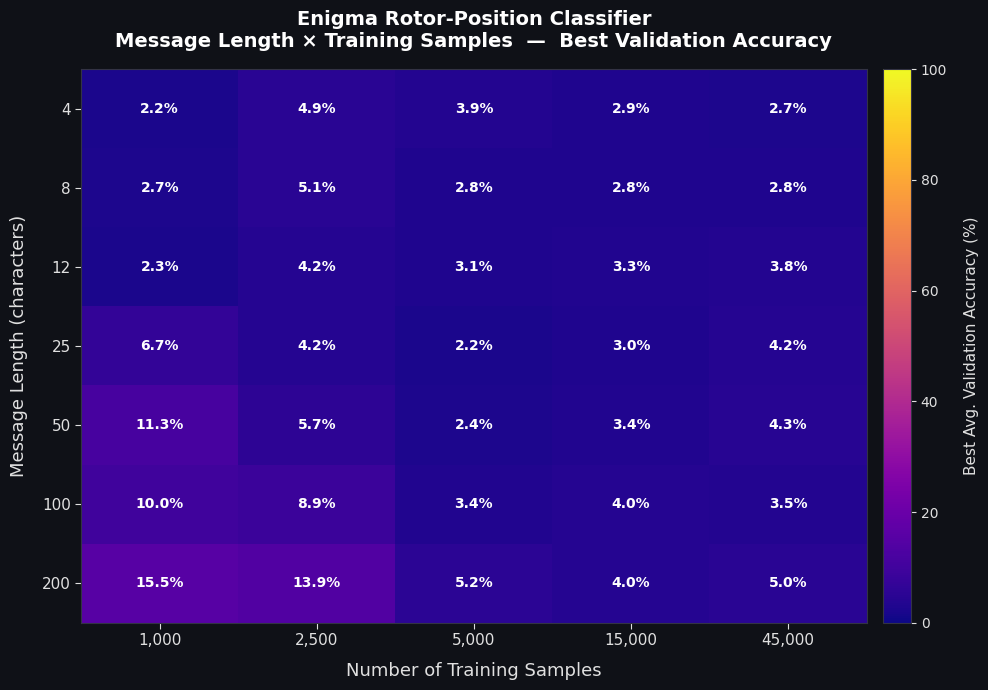


Done.


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import string
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import itertools
import json
from datetime import datetime

# Force file paths to be relative to the script location
try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR = os.getcwd()

INPUT_TEXT_FILE = os.path.join(BASE_DIR, 'The home book of verse processed.txt')

# Default Enigma configuration (same as original)
DEFAULT_ROTOR_ORDER = ['III', 'II', 'I']
DEFAULT_POSITIONS   = [0, 0, 0]

# ============================================================================
# GRID SEARCH CONFIGURATION
# ============================================================================
# Adjust these lists to change what gets tested.
# Each (message_length, num_samples) pair will be a separate training run.
MESSAGE_LENGTHS  = [4, 8, 12, 25, 50, 100, 200]       # characters per training sample
NUM_SAMPLES_LIST = [1000, 2500, 5000, 15000, 45000]  # total training + validation samples

# Training hyper-parameters (kept fixed across all runs)
NUM_EPOCHS  = 6
BATCH_SIZE  = 32
HIDDEN_DIM  = 256   # FC layer width (same as original)
STEP_SIZE   = 1     # rotor advancement between consecutive samples

# ============================================================================
# ENIGMA SIMULATOR  (identical to original)
# ============================================================================
class SimpleEnigma:
    ROTORS = {
        'I':   'EKMFLGDQVZNTOWYHXUSPAIBRCJ',
        'II':  'AJDKSIRUXBLHWTMCQGZNPYFVOE',
        'III': 'BDFHJLCPRTXVZNYEIWGAKMUSQO',
        'IV':  'ESOVPZJAYQUIRHXLNFTGKDCMWB',
        'V':   'VZBRGITYUPSDNHLXAWMJQOFECK',
    }
    NOTCHES   = {'I': 'Q', 'II': 'E', 'III': 'V', 'IV': 'J', 'V': 'Z'}
    REFLECTOR = 'YRUHQSLDPXNGOKMIEBFZCWVJAT'

    def __init__(self, rotors, positions):
        self.rotors       = [self.ROTORS[r] for r in rotors]
        self.rotor_names  = rotors
        self.positions    = positions.copy()
        self.initial_positions = positions.copy()

    def reset(self):
        self.positions = self.initial_positions.copy()

    def set_positions(self, positions):
        self.positions = positions.copy()

    def get_positions(self):
        return self.positions.copy()

    def step_rotors(self):
        if self.rotor_at_notch(1):
            self.positions[1] = (self.positions[1] + 1) % 26
            self.positions[2] = (self.positions[2] + 1) % 26
        elif self.rotor_at_notch(0):
            self.positions[1] = (self.positions[1] + 1) % 26
        self.positions[0] = (self.positions[0] + 1) % 26

    def rotor_at_notch(self, rotor_index):
        notch     = self.NOTCHES[self.rotor_names[rotor_index]]
        notch_pos = ord(notch) - ord('A')
        return self.positions[rotor_index] == notch_pos

    def encrypt_char(self, char):
        if char not in string.ascii_uppercase:
            return char
        self.step_rotors()
        pos = ord(char) - ord('A')
        for i in range(3):
            pos = (pos + self.positions[i]) % 26
            pos = ord(self.rotors[i][pos]) - ord('A')
            pos = (pos - self.positions[i]) % 26
        pos = ord(self.REFLECTOR[pos]) - ord('A')
        for i in range(2, -1, -1):
            pos = (pos + self.positions[i]) % 26
            pos = self.rotors[i].index(chr(pos + ord('A')))
            pos = (pos - self.positions[i]) % 26
        return chr(pos + ord('A'))

    def encrypt(self, text):
        return ''.join(self.encrypt_char(c) for c in text.upper())


# ============================================================================
# DATA GENERATION
# ============================================================================
def read_text_from_file(filename):
    if not os.path.exists(filename):
        raise FileNotFoundError(f"Input file '{filename}' not found!")
    letters = []
    with open(filename, 'r') as f:
        for line in f:
            for char in line.strip().upper():
                if char in string.ascii_uppercase:
                    letters.append(char)
    text = ''.join(letters)
    print(f"  Read {len(text)} letters from '{filename}'")
    return text


def generate_dataset_continuous(full_plaintext, rotor_order, initial_positions,
                                num_samples, message_length, step_size=1):
    total_chars_needed = (num_samples * step_size) + message_length
    if len(full_plaintext) < total_chars_needed:
        repeats        = (total_chars_needed // len(full_plaintext)) + 1
        full_plaintext = full_plaintext * repeats

    enigma = SimpleEnigma(rotor_order, initial_positions)
    full_ciphertext = enigma.encrypt(full_plaintext)

    enigma.set_positions(initial_positions)
    data = []
    for i in range(num_samples):
        start_idx        = i * step_size
        plaintext        = full_plaintext [start_idx: start_idx + message_length]
        ciphertext       = full_ciphertext[start_idx: start_idx + message_length]
        chunk_positions  = enigma.get_positions()
        for char in full_plaintext[start_idx: start_idx + step_size]:
            if char in string.ascii_uppercase:
                enigma.step_rotors()
        data.append({
            'ciphertext': ciphertext,
            'plaintext':  plaintext,
            'rotors':     rotor_order,
            'positions':  chunk_positions,
        })
    return data


# ============================================================================
# PYTORCH DATASET
# ============================================================================
class EnigmaDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item             = self.data[idx]
        ciphertext_enc   = self.encode_text(item['ciphertext'])
        positions        = torch.tensor(item['positions'], dtype=torch.long)
        return ciphertext_enc, positions

    @staticmethod
    def encode_text(text):
        encoded = torch.zeros(len(text), 26)
        for i, char in enumerate(text):
            if char in string.ascii_uppercase:
                encoded[i, ord(char) - ord('A')] = 1
        return encoded


# ============================================================================
# MODEL  (identical architecture to original, same node counts)
# ============================================================================
class EnigmaRotorClassifier(nn.Module):
    def __init__(self, message_length=100, hidden_dim=1024):
        super().__init__()

        self.conv1 = nn.Conv1d(26,   64,   kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(64,   128,  kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(128,  256,  kernel_size=3, padding=1)
        self.conv4 = nn.Conv1d(256,  512,  kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(512,  1024, kernel_size=3, padding=1)

        self.pool    = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.3)

        self.batch_norm1 = nn.BatchNorm1d(64)
        self.batch_norm2 = nn.BatchNorm1d(128)
        self.batch_norm3 = nn.BatchNorm1d(256)
        self.batch_norm4 = nn.BatchNorm1d(512)
        self.batch_norm5 = nn.BatchNorm1d(1024)

        self.relu = nn.ReLU()

        # Simulate the sequence length after each conv+pool step so the FC
        # input size is computed correctly regardless of message_length.
        # Pooling is skipped whenever the sequence would drop to 0.
        seq = message_length
        for _ in range(5):
            seq = seq // 2 if seq >= 2 else seq
        conv_output_size = max(seq, 1) * 1024

        self.fc1 = nn.Linear(conv_output_size, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim,       hidden_dim)

        self.rotor1_head = nn.Linear(hidden_dim, 26)
        self.rotor2_head = nn.Linear(hidden_dim, 26)
        self.rotor3_head = nn.Linear(hidden_dim, 26)

    @staticmethod
    def _pool_if_safe(pool, x):
        """Apply max-pool only when the sequence length is at least 2."""
        if x.size(2) >= 2:
            return pool(x)
        return x

    def forward(self, x):
        # x: (batch, seq_len, 26) → (batch, 26, seq_len)
        x = x.transpose(1, 2)

        x = self.relu(self.batch_norm1(self.conv1(x))); x = self._pool_if_safe(self.pool, x)
        x = self.relu(self.batch_norm2(self.conv2(x))); x = self._pool_if_safe(self.pool, x)
        x = self.relu(self.batch_norm3(self.conv3(x))); x = self._pool_if_safe(self.pool, x)
        x = self.relu(self.batch_norm4(self.conv4(x))); x = self._pool_if_safe(self.pool, x)
        x = self.relu(self.batch_norm5(self.conv5(x))); x = self._pool_if_safe(self.pool, x)

        x = x.view(x.size(0), -1)
        x = self.dropout(x)

        x = self.relu(self.fc1(x)); x = self.dropout(x)
        x = self.relu(self.fc2(x))

        return self.rotor1_head(x), self.rotor2_head(x), self.rotor3_head(x)


# ============================================================================
# SINGLE-RUN TRAINING  (returns best average validation accuracy across rotors)
# ============================================================================
def train_and_evaluate(message_length, num_samples, device, full_plaintext,
                       num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE,
                       hidden_dim=HIDDEN_DIM):
    print(f"\n  [MSG_LEN={message_length:>4d}, SAMPLES={num_samples:>5d}]  generating data …")

    dataset   = generate_dataset_continuous(
        full_plaintext   = full_plaintext,
        rotor_order      = DEFAULT_ROTOR_ORDER,
        initial_positions= DEFAULT_POSITIONS,
        num_samples      = num_samples,
        message_length   = message_length,
        step_size        = STEP_SIZE,
    )

    split_idx = int(0.8 * len(dataset))
    train_ds  = EnigmaDataset(dataset[:split_idx])
    val_ds    = EnigmaDataset(dataset[split_idx:])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=0, pin_memory=(device.type == 'cuda'))
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=0, pin_memory=(device.type == 'cuda'))

    model     = EnigmaRotorClassifier(message_length=message_length,
                                      hidden_dim=hidden_dim).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)

    best_avg_val_acc = 0.0

    for epoch in range(num_epochs):
        # --- training ---
        model.train()
        for ciphertext, positions in train_loader:
            ciphertext = ciphertext.to(device)
            positions  = positions.to(device)
            optimizer.zero_grad()
            o1, o2, o3 = model(ciphertext)
            loss = (criterion(o1, positions[:, 0]) +
                    criterion(o2, positions[:, 1]) +
                    criterion(o3, positions[:, 2]))
            loss.backward()
            optimizer.step()

        # --- validation ---
        model.eval()
        val_loss    = 0.0
        val_correct = [0, 0, 0]
        val_total   = 0
        with torch.no_grad():
            for ciphertext, positions in val_loader:
                ciphertext = ciphertext.to(device)
                positions  = positions.to(device)
                o1, o2, o3 = model(ciphertext)
                val_loss += (criterion(o1, positions[:, 0]) +
                             criterion(o2, positions[:, 1]) +
                             criterion(o3, positions[:, 2])).item()
                for k, (o, col) in enumerate(zip([o1, o2, o3], range(3))):
                    val_correct[k] += (o.argmax(1) == positions[:, col]).sum().item()
                val_total += positions.size(0)

        scheduler.step(val_loss)

        val_accs    = [(c / val_total) * 100 for c in val_correct]
        avg_val_acc = sum(val_accs) / 3

        if avg_val_acc > best_avg_val_acc:
            best_avg_val_acc = avg_val_acc

        print(f"    Epoch {epoch+1:>2d}/{num_epochs}  "
              f"val_acc R1={val_accs[0]:.1f}% R2={val_accs[1]:.1f}% R3={val_accs[2]:.1f}%  "
              f"avg={avg_val_acc:.1f}%  best={best_avg_val_acc:.1f}%")

    return best_avg_val_acc


# ============================================================================
# HEATMAP PLOTTING
# ============================================================================
def plot_heatmap(results_grid, message_lengths, num_samples_list, save_path):
    """
    results_grid[i][j] = best avg val accuracy for
        message_lengths[i]  x  num_samples_list[j]
    """
    data_array = np.array(results_grid)   # shape: (len(ML), len(NS))

    fig, ax = plt.subplots(figsize=(10, 7))
    fig.patch.set_facecolor('#0f1117')
    ax.set_facecolor('#0f1117')

    # ---- colour map ----
    cmap = plt.cm.get_cmap('plasma')
    im   = ax.imshow(data_array, cmap=cmap, aspect='auto',
                     vmin=0, vmax=100, interpolation='nearest')

    # ---- axes ticks ----
    ax.set_xticks(range(len(num_samples_list)))
    ax.set_xticklabels([f'{n:,}' for n in num_samples_list],
                       color='#e0e0e0', fontsize=11)

    ax.set_yticks(range(len(message_lengths)))
    ax.set_yticklabels([str(m) for m in message_lengths],
                       color='#e0e0e0', fontsize=11)

    ax.set_xlabel('Number of Training Samples', color='#e0e0e0', fontsize=13, labelpad=10)
    ax.set_ylabel('Message Length (characters)',  color='#e0e0e0', fontsize=13, labelpad=10)

    ax.tick_params(colors='#e0e0e0', length=4)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333344')

    # ---- cell annotations ----
    for i in range(len(message_lengths)):
        for j in range(len(num_samples_list)):
            val      = data_array[i, j]
            txt_col  = 'white' if val < 60 else '#111111'
            ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                    fontsize=10, fontweight='bold', color=txt_col)

    # ---- colour bar ----
    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label('Best Avg. Validation Accuracy (%)',
                   color='#e0e0e0', fontsize=11, labelpad=12)
    cbar.ax.yaxis.set_tick_params(color='#e0e0e0')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#e0e0e0')
    cbar.outline.set_edgecolor('#333344')

    # ---- title ----
    ax.set_title('Enigma Rotor-Position Classifier\n'
                 'Message Length × Training Samples  —  Best Validation Accuracy',
                 color='#ffffff', fontsize=14, fontweight='bold', pad=16)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    print(f"\n  Heatmap saved → {save_path}")
    plt.show()


# ============================================================================
# MAIN
# ============================================================================
if __name__ == '__main__':
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using device: {device}')
    print(f'Grid: message_lengths={MESSAGE_LENGTHS}  ×  num_samples={NUM_SAMPLES_LIST}')
    print(f'Epochs per run: {NUM_EPOCHS} | Batch size: {BATCH_SIZE} | Hidden dim: {HIDDEN_DIM}')
    total_runs = len(MESSAGE_LENGTHS) * len(NUM_SAMPLES_LIST)
    print(f'Total training runs: {total_runs}\n')

    # Read the input file ONCE and reuse across all runs
    print('Loading input text file …')
    full_plaintext = read_text_from_file(INPUT_TEXT_FILE)
    print()

    # results_grid[i][j] corresponds to MESSAGE_LENGTHS[i], NUM_SAMPLES_LIST[j]
    results_grid = []
    run_number   = 0

    for i, msg_len in enumerate(MESSAGE_LENGTHS):
        row = []
        for j, n_samples in enumerate(NUM_SAMPLES_LIST):
            run_number += 1
            print(f"\n{'='*60}")
            print(f"RUN {run_number}/{total_runs}  |  "
                  f"msg_len={msg_len}  n_samples={n_samples}")
            print('='*60)

            best_acc = train_and_evaluate(
                message_length = msg_len,
                num_samples    = n_samples,
                device         = device,
                full_plaintext = full_plaintext,
            )
            row.append(best_acc)
            print(f"  → Best avg val accuracy: {best_acc:.2f}%")

        results_grid.append(row)

    # ---- save raw results ----
    timestamp    = datetime.now().strftime('%Y%m%d_%H%M%S')
    results_path = os.path.join(BASE_DIR, f'enigma_grid_results_{timestamp}.json')
    with open(results_path, 'w') as f:
        json.dump({
            'message_lengths':  MESSAGE_LENGTHS,
            'num_samples_list': NUM_SAMPLES_LIST,
            'results_grid':     results_grid,
            'timestamp':        timestamp,
        }, f, indent=2)
    print(f"\nRaw results saved → {results_path}")

    # ---- print summary table ----
    print('\n' + '='*60)
    print('RESULTS SUMMARY  (best avg val accuracy %)')
    print('='*60)
    header = f"{'ML\\NS':>8}" + ''.join(f'{n:>10,}' for n in NUM_SAMPLES_LIST)
    print(header)
    print('-'*60)
    for i, msg_len in enumerate(MESSAGE_LENGTHS):
        row_str = f"{msg_len:>8}" + ''.join(f'{results_grid[i][j]:>9.2f}%'
                                             for j in range(len(NUM_SAMPLES_LIST)))
        print(row_str)

    # ---- plot heatmap ----
    heatmap_path = os.path.join(BASE_DIR, f'enigma_heatmap_{timestamp}.png')
    plot_heatmap(results_grid, MESSAGE_LENGTHS, NUM_SAMPLES_LIST, heatmap_path)

    print('\nDone.')